In [1]:
import scipy.stats as stat
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sea
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import skew

In [2]:
df = pd.read_csv('Salary Data.csv')
data_salary = df.copy()

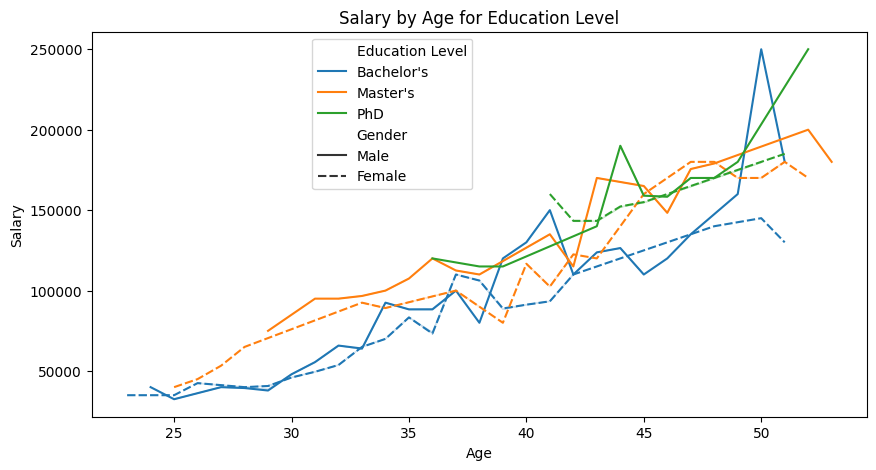

In [ ]:
plt.figure(figsize=(10,5))
sea.lineplot(x = data_salary["Age"], y =data_salary["Salary"],hue=data_salary["Education Level"], style= data_salary["Gender"],ci=1).set(title= 'Salary by Age for Education Level')
plt.legend(bbox_to_anchor=(0.5, 1)) #yo line mathi ko ci lai badhaye ni kei hunna ghatayeni kei hunna tara remove gare chai hunxa
plt.show() #style le chai extra parameter lyayo yesma chai gender ko ni lyayo

In [6]:
#CROSS TAB
df_edu_gender = pd.crosstab(index= data_salary['Education Level'], columns=data_salary['Gender'], values = data_salary['Salary'], aggfunc=['mean'])
df_edu_gender


mean               
Gender                  Female           Male
Education Level                              
Bachelor's        71019.417476   77936.776860
Master's         120200.000000  139791.666667
PhD              155384.615385  160400.000000

In [5]:
  df_exp_gender = pd.crosstab(index = data_salary['Years of Experience'], columns=data_salary['Gender'], values=data_salary['Salary'], aggfunc=['mean'])
  df_exp_gender

mean               
Gender                      Female           Male
Years of Experience                              
0.0                   35000.000000   32500.000000
0.5                   35000.000000            NaN
1.0                   40000.000000   36250.000000
1.5                   41428.571429   29070.000000
2.0                   41923.076923   41666.666667
3.0                   48750.000000   53928.571429
4.0                   53333.333333   60714.285714
5.0                   62272.727273   67500.000000
6.0                   83333.333333   84166.666667
7.0                   70000.000000   87333.333333
8.0                   84166.666667   93076.923077
9.0                  100000.000000  102666.666667
10.0                  95769.230769  113000.000000
11.0                  94166.666667  110000.000000
12.0                  99090.909091  121250.000000
13.0                 112857.142857  132500.000000
14.0                 120000.000000  130714.285714
15.0                 134285.714286  135000.000000
16.0                 158888.888889  156111.111111
17.0                 130000.000000  151666.666667
18.0                 146000.000000  151875.000000
19.0                 150000.000000  167500.000000
20.0                 180000.000000  163888.888889
21.0                 178333.333333  170000.000000
22.0                 160000.000000  166666.666667
23.0                 177500.000000            NaN
24.0                           NaN  250000.000000
25.0                 170000.000000  215000.000000

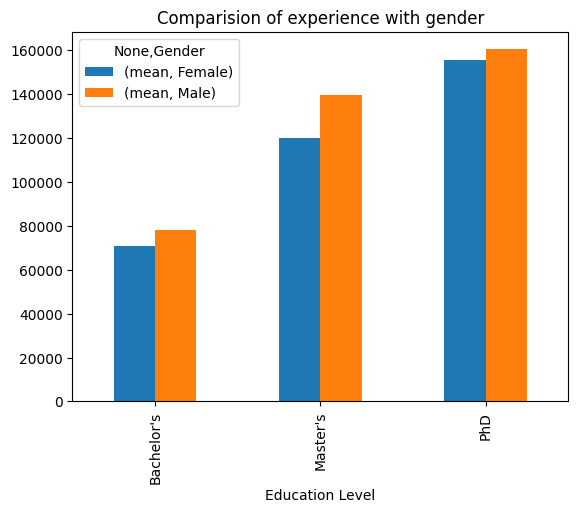

In [9]:
#plotting directly from dataframe
df_edu_gender.plot(kind = "bar", title ="Comparision of experience with gender")
plt.legend
plt.show()

In [10]:
data_salary

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0


In [21]:
#qualitative data to quantitave
try:
  huh = pd.cut(data_salary.Age, bins =[0,10,20,30,40,50,60,70], labels=['0-10','10-20','20-30','30-40','40-50','50-60','60-70'])
  print(huh)
  data_salary.insert(1,"group_age", huh)
except:
  print("wtf")

0      30-40
1      20-30
2      40-50
3      30-40
4      50-60
       ...  
370    30-40
371    40-50
372    20-30
373    30-40
374    40-50
Name: Age, Length: 375, dtype: category
Categories (7, object): ['0-10' < '10-20' < '20-30' < '30-40' < '40-50' < '50-60' < '60-70']
wtf


In [22]:
data_salary


,Age,group_age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,20-30,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,10-20,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,30-40,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,20-30,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,40-50,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...,...
370,35.0,20-30,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,30-40,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,10-20,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,20-30,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0


In [24]:
data_salary.groupby('group_age')['Salary'].mean()

,Salary
group_age,
0-10,NaN
10-20,42676.027397
20-30,84166.666667
30-40,151260.162602
40-50,183888.888889
50-60,NaN


In [27]:
#group by
try:
  exp_bin = pd.cut(data_salary['Years of Experience'], bins = [0,5,10,15,20,25,30], labels=['0-5','5-10','10-15','15-20','20-25','25-30'])
  data_salary.insert(4,'exp_bin',exp_bin)
except:
  print("e")

In [28]:
data_salary

,Age,group_age,Gender,Education Level,exp_bin,Job Title,Years of Experience,Salary
0,32.0,20-30,Male,Bachelor's,0-5,Software Engineer,5.0,90000.0
1,28.0,10-20,Female,Master's,0-5,Data Analyst,3.0,65000.0
2,45.0,30-40,Male,PhD,10-15,Senior Manager,15.0,150000.0
3,36.0,20-30,Female,Bachelor's,5-10,Sales Associate,7.0,60000.0
4,52.0,40-50,Male,Master's,15-20,Director,20.0,200000.0
...,...,...,...,...,...,...,...,...
370,35.0,20-30,Female,Bachelor's,5-10,Senior Marketing Analyst,8.0,85000.0
371,43.0,30-40,Male,Master's,15-20,Director of Operations,19.0,170000.0
372,29.0,10-20,Female,Bachelor's,0-5,Junior Project Manager,2.0,40000.0
373,34.0,20-30,Male,Bachelor's,5-10,Senior Operations Coordinator,7.0,90000.0


In [35]:
data_salary.groupby(['Gender','Education Level','exp_bin']).Salary.mean()


Gender  Education Level  exp_bin
Female  Bachelor's       0-5         47040.816327
                         5-10        88225.806452
                         10-15       92941.176471
                         15-20      120000.000000
                         20-25      140000.000000
                         25-30                NaN
        Master's         0-5         58750.000000
                         5-10        93000.000000
                         10-15      115000.000000
                         15-20      170000.000000
                         20-25      176250.000000
                         25-30                NaN
        PhD              0-5                  NaN
                         5-10                 NaN
                         10-15      147727.272727
                         15-20      153636.363636
                         20-25      181250.000000
                         25-30                NaN
Male    Bachelor's       0-5         49158.474576
                         5-10        90833.333333
                         10-15      125384.615385
                         15-20      121875.000000
                         20-25      196666.666667
                         25-30                NaN
        Master's         0-5         75000.000000
                         5-10       102941.176471
                         10-15      126250.000000
                         15-20      172750.000000
                         20-25      170000.000000
                         25-30                NaN
        PhD              0-5                  NaN
                         5-10       110000.000000
                         10-15      126250.000000
                         15-20      164333.333333
                         20-25      186000.000000
                         25-30                NaN
Name: Salary, dtype: float64

<Axes: xlabel='Gender,Education Level,exp_bin'>

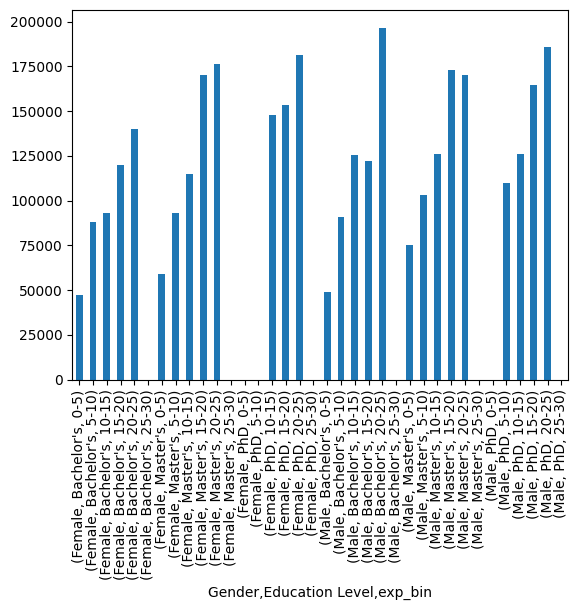

In [38]:
data_salary.groupby(['Gender', 'Education Level', 'exp_bin']).Salary.mean().plot.bar()

In [41]:
data_salary.groupby(['Gender', 'Education Level', 'exp_bin']).Salary.mean().unstack()

exp_bin                          0-5           5-10          10-15  \
Gender Education Level                                               
Female Bachelor's       47040.816327   88225.806452   92941.176471   
       Master's         58750.000000   93000.000000  115000.000000   
       PhD                       NaN            NaN  147727.272727   
Male   Bachelor's       49158.474576   90833.333333  125384.615385   
       Master's         75000.000000  102941.176471  126250.000000   
       PhD                       NaN  110000.000000  126250.000000   

exp_bin                         15-20          20-25  25-30  
Gender Education Level                                       
Female Bachelor's       120000.000000  140000.000000    NaN  
       Master's         170000.000000  176250.000000    NaN  
       PhD              153636.363636  181250.000000    NaN  
Male   Bachelor's       121875.000000  196666.666667    NaN  
       Master's         172750.000000  170000.000000    NaN  
       PhD              164333.333333  186000.000000    NaN

<Axes: xlabel='Gender,Education Level'>

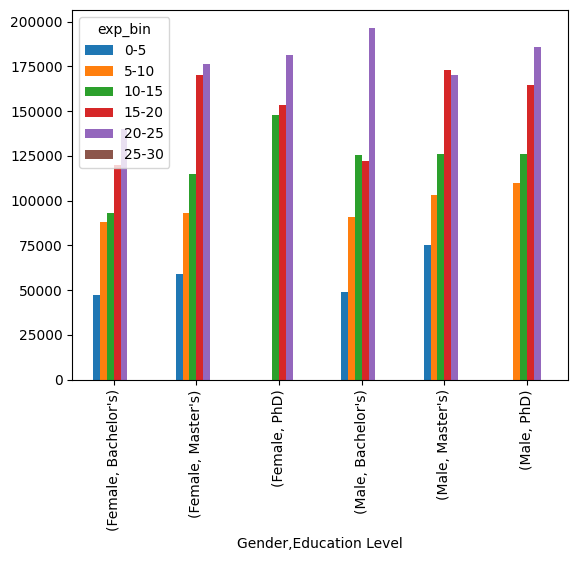

In [40]:
data_salary.groupby(['Gender','Education Level',"exp_bin"]).Salary.mean().unstack().plot.bar()

In [45]:
import plotly.express as plot
not_fig = plot.scatter(data_salary, x = "Age", y = "Salary",
size = "Years of Experience", color = "Education Level",
hover_name = "Job Title", size_max = 60)

not_fig.show()

In [47]:
a_fig = plot.scatter_3d(data_salary, x="Age", y="Salary",
                        size ="Years of Experience", color="Education Level",
                        hover_name = "Job Title", size_max=60)
a_fig.show()